# 11 · Descriptivos avanzados del subcorpus COM-B

Equivalente al notebook `13_ciencia_admin_descriptivos.ipynb` de Karen.
Integra NER (NB06) y POS (NB08) para producir un análisis descriptivo
completo del subcorpus COM-B, con comparación por subcomponente.

**Entradas:**
- `comb_tweets_final.parquet`
- `corpus_cleaned.parquet`
- `general_ner.parquet`
- `verbos_comb_stanza.parquet` *(si NB08 ya corrió)*
- `adjetivos_comb_stanza.parquet` *(si NB08 ya corrió)*
- `sustantivos_comb_stanza.parquet` *(si NB08 ya corrió)*

**Salidas:** `descriptivos_avanzados_comb.xlsx`, figuras


In [1]:
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

COLS_SUBCATS = [
    'COMB_Capacidad_fisica',
    'COMB_Capacidad_psicologica',
    'COMB_Motivacion_automatica',
    'COMB_Motivacion_reflexiva',
    'COMB_Oportunidad_fisica',
    'COMB_Oportunidad_social',
]

# En COM-B los 6 subcomponentes son principales
SUBCATS_PRINCIPALES = COLS_SUBCATS

print('[CONFIG] OK')


[CONFIG] OK


In [2]:
import ast, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import spacy
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comb_tweets_final.parquet')

df_comp  = tweets_comp.merge(
    corpus[['id_doc', 'Author_Normalized', 'Entidad', 'Fecha', 'Texto_limpio']],
    on='id_doc', how='left'
)
df_comp['Fecha']  = pd.to_datetime(df_comp['Fecha'], errors='coerce')

print(f'Corpus completo  : {len(corpus):,} tweets')
print(f'Subcorpus comp.  : {len(df_comp):,} tweets')
df_comp.head(2)


Corpus completo  : 151,424 tweets
Subcorpus comp.  : 12,254 tweets


,chunk_id,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social,score_max,subcat_max,etiqueta_comb,categoria_detectada,Author_Normalized,Entidad,Fecha,Texto_limpio
0,5_1,5,Local Gestionan regidores cajas para intubació...,0.374892,0.315076,0.261424,0.284109,0.510342,0.272318,0.510342,COMB_Oportunidad_fisica,1,COMB_Oportunidad_fisica,@cscnoticias1,"Noticias locales, nacionales o globales",2020-06-03,Local Gestionan regidores cajas para intubació...
1,6_1,6,La otra semana ya saldrá el aumento de contagi...,0.281226,0.367581,0.299257,0.363866,0.482989,0.208974,0.482989,COMB_Oportunidad_fisica,1,COMB_Oportunidad_fisica,@bebita11385037,Autoridad local de salud o gobierno,2020-06-03,La otra semana ya saldrá el aumento de contagi...


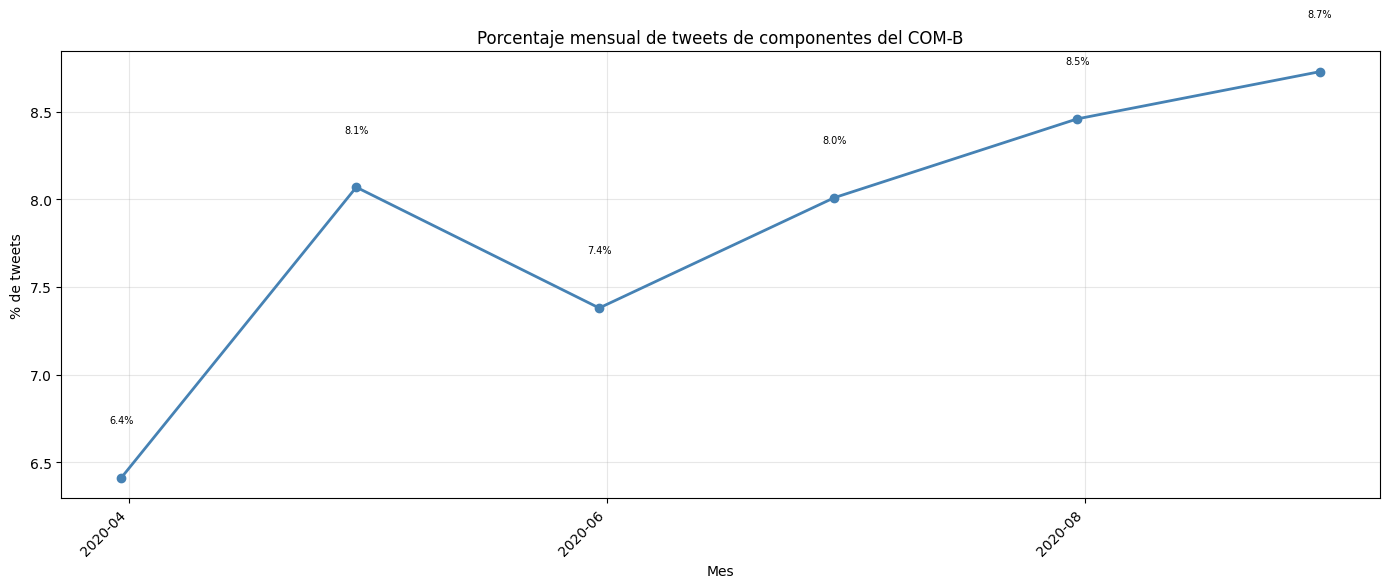

[GUARDADO] fig_porcentaje_mensual_comportamiento_avanzado.png


In [3]:
# Porcentaje mensual comportamientos / corpus total (replica de Karen)
total_mensual = corpus.groupby(pd.Grouper(key='Fecha', freq='ME')).size()
comp_mensual  = df_comp.groupby(pd.Grouper(key='Fecha', freq='ME'))['id_doc'].nunique()

mensual = pd.DataFrame({'total': total_mensual, 'comp': comp_mensual}).fillna(0)
mensual['porcentaje'] = (mensual['comp'] / mensual['total'] * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(mensual.index, mensual['porcentaje'], marker='o', linestyle='-', color='steelblue', linewidth=2)
ax.set_title('Porcentaje mensual de tweets de componentes del COM-B')
ax.set_ylabel('% de tweets')
ax.set_xlabel('Mes')
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
for x, y in zip(mensual.index, mensual['porcentaje']):
    if not np.isnan(y) and y > 0:
        ax.text(x, y + 0.3, f'{y:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_comportamiento_avanzado.png', dpi=300)
plt.show()
print('[GUARDADO] fig_porcentaje_mensual_comportamiento_avanzado.png')


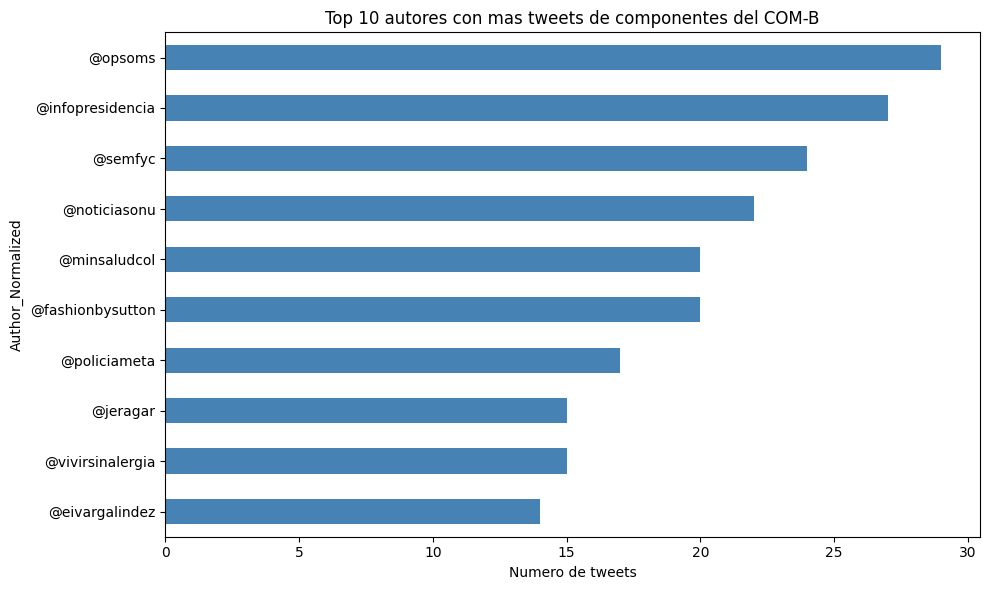

[GUARDADO] fig_top_autores_comportamiento_avanzado.png


In [4]:
# Top autores en subcorpus del COM-B (replica de Karen)
top_autores = df_comp['Author_Normalized'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_autores.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 autores con mas tweets de componentes del COM-B')
ax.set_xlabel('Numero de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_autores_comportamiento_avanzado.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_autores_comportamiento_avanzado.png')


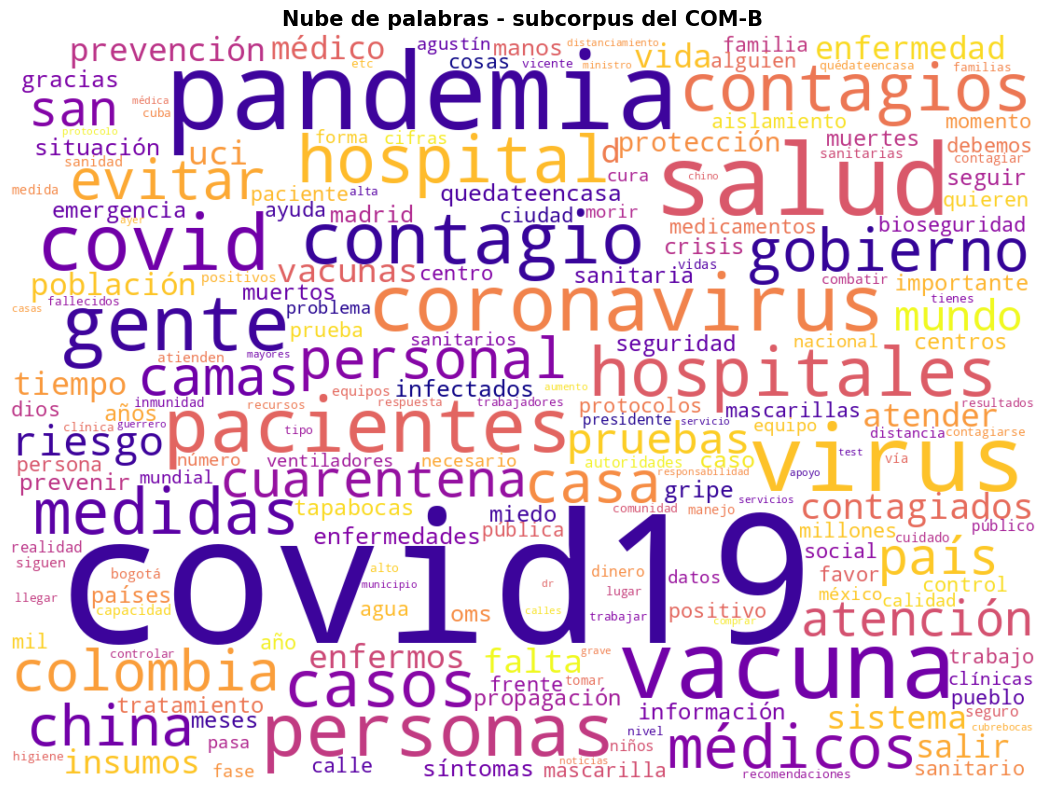

[GUARDADO] nube_subcorpus_comportamiento_avanzado.png


In [5]:
# Nube de palabras del subcorpus del COM-B (replica de Karen)
nlp = spacy.load('es_core_news_sm')
STOP_WORDS = nlp.Defaults.stop_words
extra_sw = {'rt', 'http', 'https', 'co', 'amp', 'q', 'x', 'xq', 'via'}
STOP_WORDS = STOP_WORDS | extra_sw

texto_comp  = ' '.join(df_comp['Texto_limpio'].dropna().tolist()).lower()

wc = WordCloud(
    width=1100, height=800, background_color='white',
    max_words=200, stopwords=STOP_WORDS,
    prefer_horizontal=1.0, relative_scaling=0.5,
    collocations=False, random_state=42,
    min_font_size=10, colormap='plasma',
    normalize_plurals=False
).generate(texto_comp)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('Nube de palabras - subcorpus del COM-B', fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_subcorpus_comportamiento_avanzado.png', dpi=300)
plt.show()
print('[GUARDADO] nube_subcorpus_comportamiento_avanzado.png')


In [6]:
# Analisis NER: extraer y tabular entidades (replica de Karen)
def extract_entities(entities_array):
    entities_list = []
    if entities_array is None:
        return entities_list
    try:
        for item in entities_array:
            if hasattr(item, '__len__') and len(item) >= 2:
                entities_list.append((str(item[0]), str(item[1])))
    except Exception:
        pass
    return entities_list

ner_general = pd.read_parquet(DATA_PROCESSED / 'general_ner.parquet')
comb_ids = set(df_comp['id_doc'])
ner_comp  = ner_general[ner_general['id_doc'].isin(comb_ids)].copy()
print(f'Tweets en general_ner  : {len(ner_general):,}')
print(f'Tweets del COM-B en NER  : {len(ner_comp):,}')


Tweets en general_ner  : 151,424
Tweets del COM-B en NER  : 12,254


In [7]:
# Tabla de entidades comportamientos vs corpus completo (replica directa de Karen)
entidades_con_etiqueta = []

for _, row in tqdm(ner_general.iterrows(), total=len(ner_general), desc='NER global'):
    entidades = extract_entities(row['entidades'])
    es_comp   = 1 if row['id_doc'] in comb_ids else 0
    for tipo, nombre in entidades:
        entidades_con_etiqueta.append({'tipo': tipo, 'nombre': nombre, 'etiqueta_comb': es_comp})

df_ent = pd.DataFrame(entidades_con_etiqueta)

resultado_ner = (
    df_ent.groupby(['tipo', 'nombre'])
    .agg(frecuencia_total=('etiqueta_comb', 'size'),
         frecuencia_comp=('etiqueta_comb', lambda x: (x == 1).sum()))
    .reset_index()
)
resultado_ner['frecuencia_no_comp']  = resultado_ner['frecuencia_total'] - resultado_ner['frecuencia_comp']
resultado_ner['cociente_comp']  = (resultado_ner['frecuencia_comp'] / resultado_ner['frecuencia_total']).round(4)
resultado_ner.columns = ['Tipo','Entidad','Frecuencia_Total','Frecuencia_Comp','Frecuencia_No_Comp','Cociente_Comp']
resultado_ner = resultado_ner.sort_values('Frecuencia_Total', ascending=False).reset_index(drop=True)

print(f'Entidades unicas: {len(resultado_ner):,}')
print(resultado_ner.head(15).to_string(index=False))


NER global: 100%|██████████| 151424/151424 [00:02<00:00, 50905.47it/s]


Entidades unicas: 85,662
Tipo   Entidad  Frecuencia_Total  Frecuencia_Comp  Frecuencia_No_Comp  Cociente_Comp
MISC        Co             12742              811               11931         0.0636
MISC   Covid19              9697             1095                8602         0.1129
 LOC  Colombia              8852              437                8415         0.0494
 LOC     China              7800              392                7408         0.0503
MISC   COVID19              6831             1030                5801         0.1508
MISC     Covid              5589              481                5108         0.0861
 LOC    Madrid              5012              181                4831         0.0361
MISC        CO              4294              409                3885         0.0952
MISC     COVID              2479              244                2235         0.0984
 LOC    Bogotá              2414              118                2296         0.0489
 LOC      Cuba              2229        

In [8]:
# Analisis POS: frecuencias por subcategoria (replica de Karen)
# Karen compara freq_ciencia vs freq_total.
# Aqui la comparacion util es por subcategoria del COM-B.
import ast

def asegurar_dict(x):
    if isinstance(x, dict):
        return {k: int(v) for k, v in x.items() if k is not None and v is not None}
    if isinstance(x, str):
        try:
            d = ast.literal_eval(x)
            return {k: int(v) for k, v in d.items() if k is not None and v is not None}
        except:
            return {}
    return {}


def construir_tabla_frecuencias_pos(df_pos, columna_dicts,
                                     df_comp_meta=None,
                                     subcats_principales=None):
    freq_total = Counter()
    freq_por_subcat = {s: Counter() for s in (subcats_principales or [])}

    # df_pos ya tiene subcat_max (guardada en NB08) -> usar directo
    if 'subcat_max' in df_pos.columns:
        df_work = df_pos.copy()
    elif df_comp_meta is not None:
        df_work = df_pos.merge(df_comp_meta[['id_doc', 'subcat_max']], on='id_doc', how='left')
    else:
        df_work = df_pos.copy()
        df_work['subcat_max'] = 'desconocida'

    for _, row in tqdm(df_work.iterrows(), total=len(df_work)):
        dic = asegurar_dict(row[columna_dicts])
        if not dic:
            continue
        freq_total.update(dic)
        subcat = row.get('subcat_max', '')
        if subcat in freq_por_subcat:
            freq_por_subcat[subcat].update(dic)

    data = []
    for palabra, f_total in freq_total.items():
        row_data = {'palabra': palabra, 'frecuencia_total': f_total}
        for s in (subcats_principales or []):
            label = s.replace('COMB_', '')
            f_s = freq_por_subcat[s].get(palabra, 0)
            row_data['freq_' + label] = f_s
            row_data['prop_' + label] = round(f_s / f_total, 4) if f_total > 0 else 0
        data.append(row_data)

    if not data:
        return pd.DataFrame()
    return pd.DataFrame(data).sort_values('frecuencia_total', ascending=False).reset_index(drop=True)


SUBCATS_PRINCIPALES = [
    'COMB_Lavado_manos',
    'COMB_Mascarilla',
    'COMB_Distanciamiento',
    'COMB_Evitar_reuniones',
    'COMB_Desinfectante',
]

try:
    df_verbos      = pd.read_parquet(DATA_PROCESSED / 'verbos_comb_stanza.parquet')
    df_adjetivos   = pd.read_parquet(DATA_PROCESSED / 'adjetivos_comb_stanza.parquet')
    df_sustantivos = pd.read_parquet(DATA_PROCESSED / 'sustantivos_comb_stanza.parquet')

    comp_meta  = tweets_comp[['id_doc', 'subcat_max']].copy()

    print('subcat_max en df_verbos:', 'subcat_max' in df_verbos.columns)
    print('Construyendo tabla de verbos...')
    tabla_verbos = construir_tabla_frecuencias_pos(
        df_verbos, 'verbos_lemas_frecuencias', comp_meta, SUBCATS_PRINCIPALES)
    print('Construyendo tabla de adjetivos...')
    tabla_adjetivos = construir_tabla_frecuencias_pos(
        df_adjetivos, 'adjetivos_lemas_frecuencias', comp_meta, SUBCATS_PRINCIPALES)
    print('Construyendo tabla de sustantivos...')
    tabla_sustantivos = construir_tabla_frecuencias_pos(
        df_sustantivos, 'sustantivos_lemas_frecuencias', comp_meta, SUBCATS_PRINCIPALES)

    POS_OK = True
    print('POS OK')
    print('Columnas:', list(tabla_verbos.columns[:6]))
except FileNotFoundError:
    POS_OK = False
    print('[SKIP] Archivos POS no encontrados. Ejecuta primero el notebook 08.')


subcat_max en df_verbos: True
Construyendo tabla de verbos...


100%|██████████| 12254/12254 [00:01<00:00, 10851.47it/s]


Construyendo tabla de adjetivos...


100%|██████████| 12254/12254 [00:01<00:00, 10373.80it/s]


Construyendo tabla de sustantivos...


100%|██████████| 12254/12254 [00:02<00:00, 4196.46it/s]


POS OK
Columnas: ['palabra', 'frecuencia_total', 'freq_Lavado_manos', 'prop_Lavado_manos', 'freq_Mascarilla', 'prop_Mascarilla']


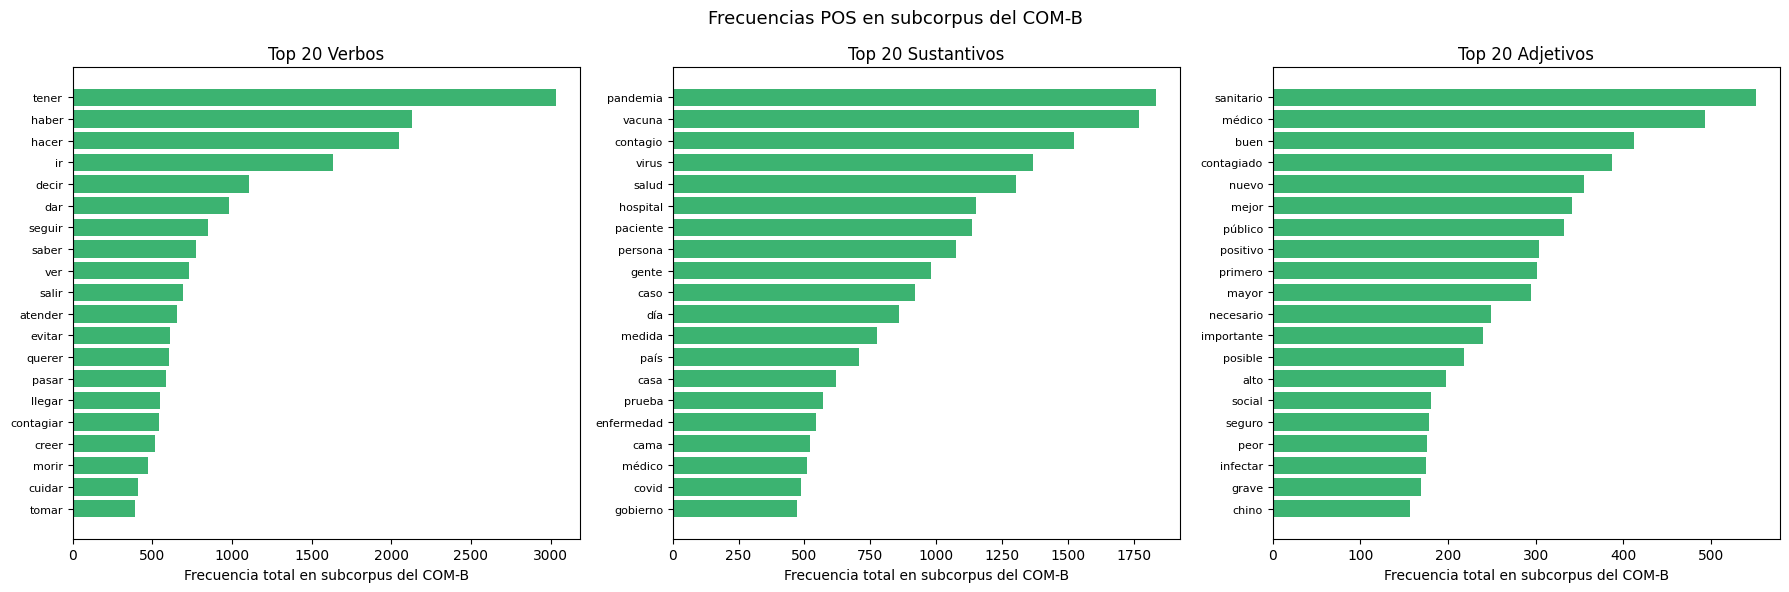

[GUARDADO] fig_pos_top_palabras_comp.png


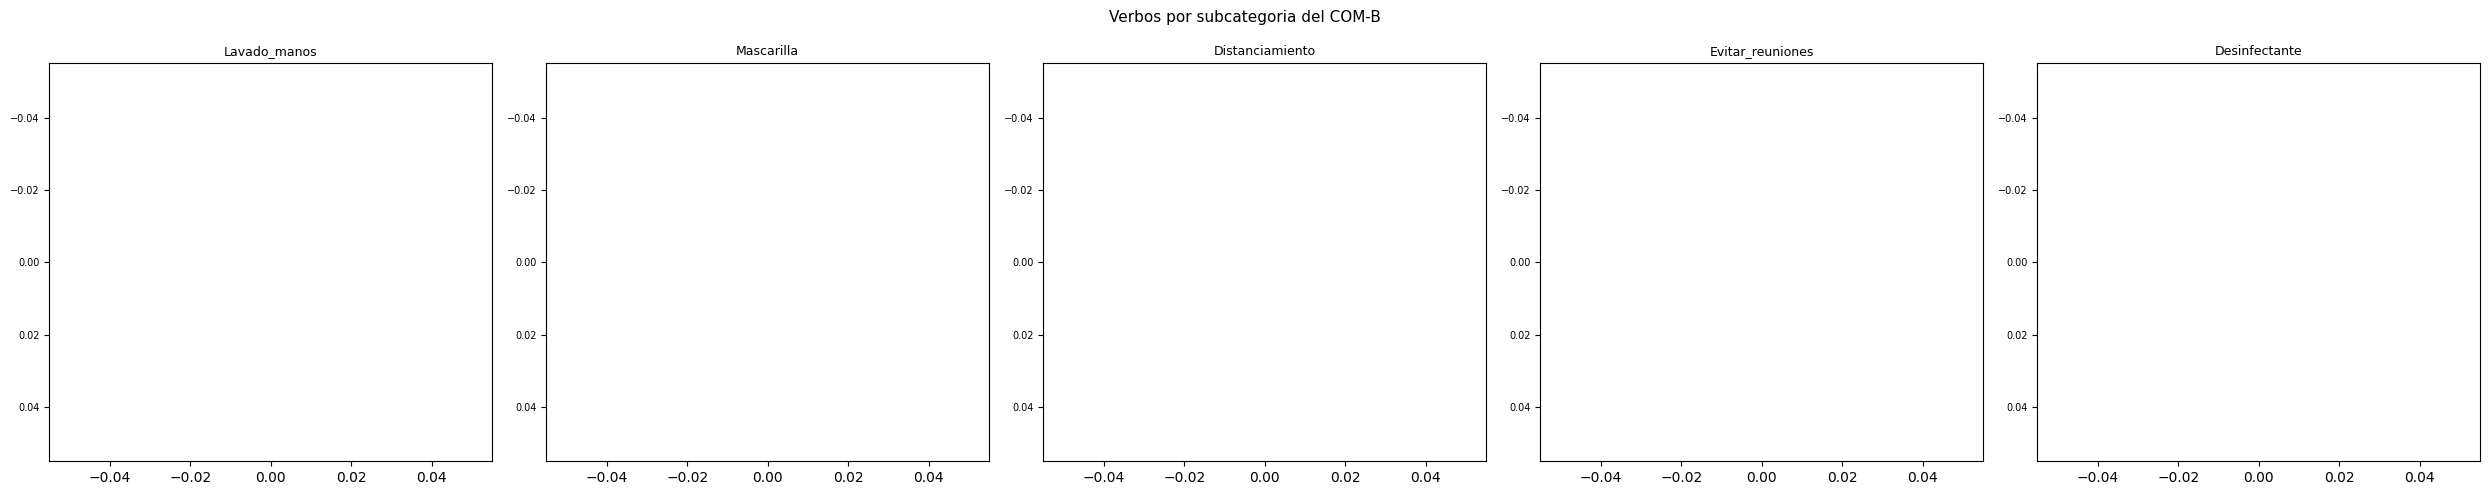

[GUARDADO] fig_pos_verbos_por_subcat.png


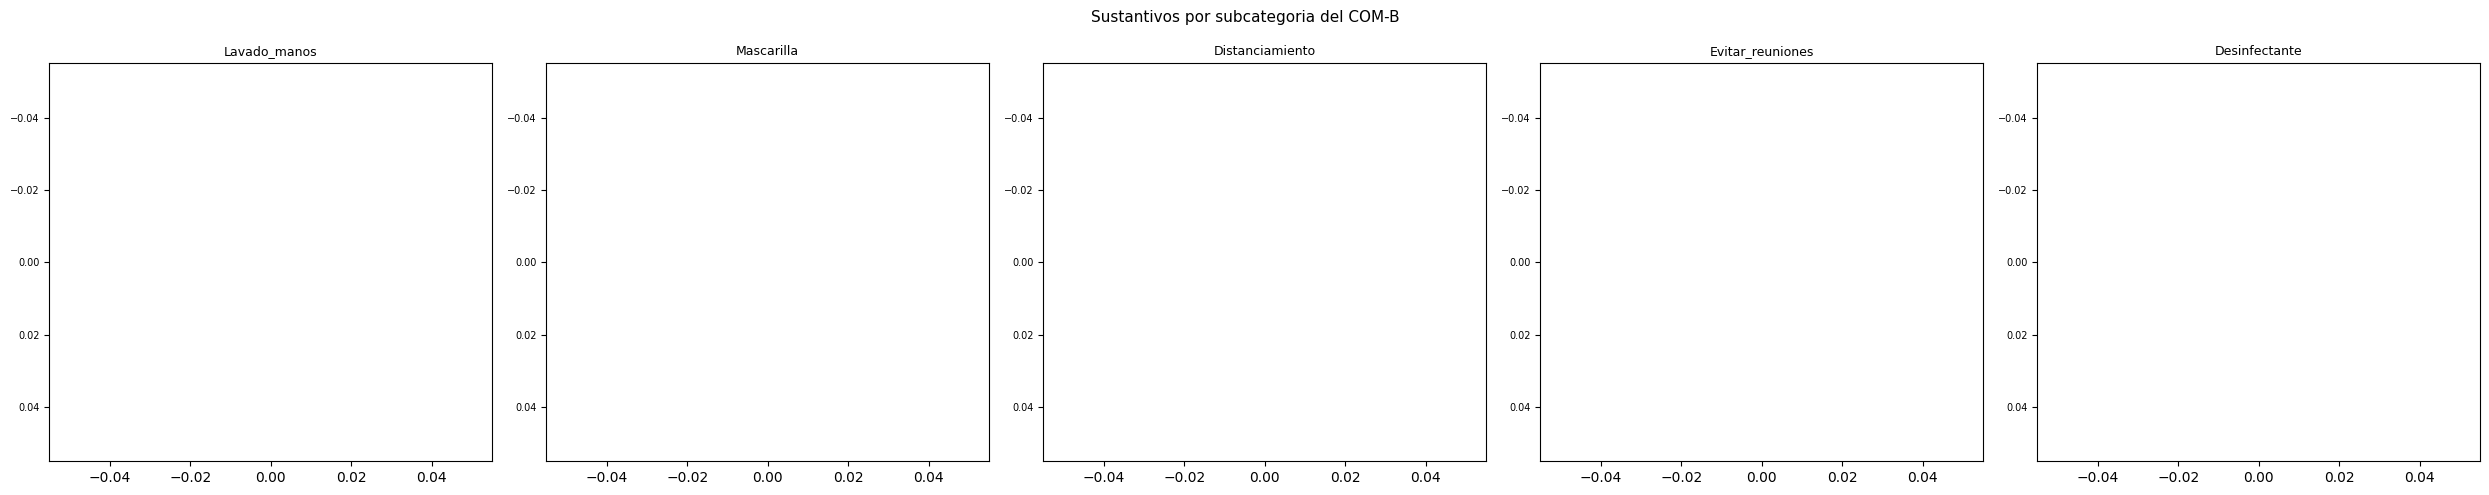

[GUARDADO] fig_pos_sustantivos_por_subcat.png


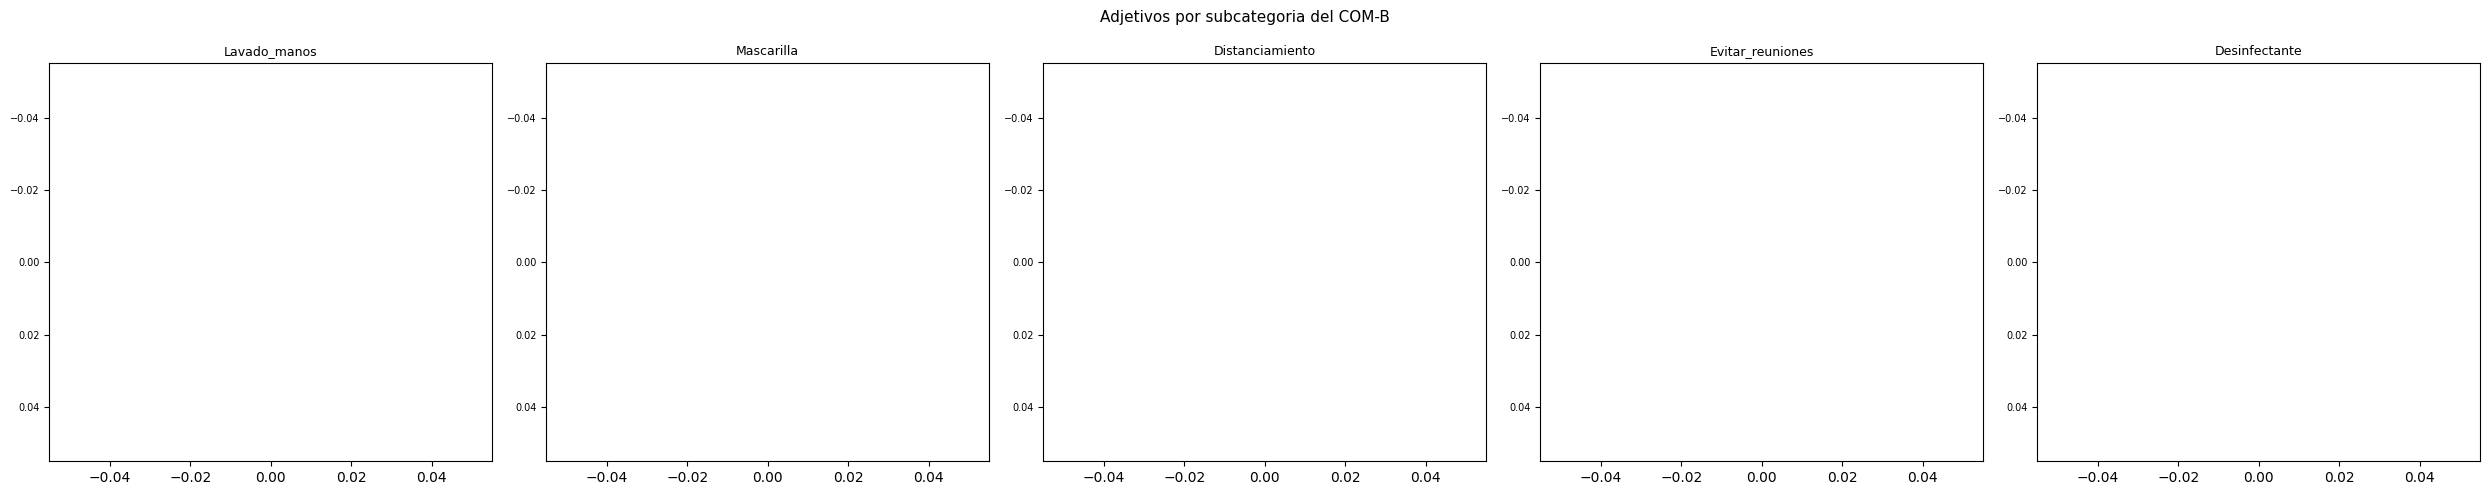

[GUARDADO] fig_pos_adjetivos_por_subcat.png


In [9]:
if POS_OK:
    # Grafico 1: top 20 por frecuencia total
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, tabla, titulo in zip(
        axes,
        [tabla_verbos, tabla_sustantivos, tabla_adjetivos],
        ['Top 20 Verbos', 'Top 20 Sustantivos', 'Top 20 Adjetivos']
    ):
        top20 = tabla.head(20).sort_values('frecuencia_total', ascending=True)
        ax.barh(top20['palabra'], top20['frecuencia_total'], color='mediumseagreen')
        ax.set_title(titulo)
        ax.set_xlabel('Frecuencia total en subcorpus del COM-B')
        ax.tick_params(axis='y', labelsize=8)
    plt.suptitle('Frecuencias POS en subcorpus del COM-B', fontsize=13)
    plt.tight_layout()
    plt.savefig(DATA_PROCESSED / 'fig_pos_top_palabras_comp.png', dpi=300)
    plt.show()
    print('[GUARDADO] fig_pos_top_palabras_comp.png')

    # Grafico 2: top 10 por subcategoria
    for tabla, tipo in [(tabla_verbos, 'Verbos'), (tabla_sustantivos, 'Sustantivos'), (tabla_adjetivos, 'Adjetivos')]:
        fig, axes = plt.subplots(1, len(SUBCATS_PRINCIPALES), figsize=(5*len(SUBCATS_PRINCIPALES), 5))
        for ax, subcat in zip(axes, SUBCATS_PRINCIPALES):
            col = 'freq_' + subcat.replace('COMB_', '')
            if col not in tabla.columns:
                ax.set_visible(False)
                continue
            top10 = tabla[tabla[col] > 0].nlargest(10, col)
            ax.barh(top10['palabra'], top10[col], color='steelblue')
            ax.set_title(subcat.replace('COMB_', ''), fontsize=9)
            ax.tick_params(axis='y', labelsize=7)
            ax.invert_yaxis()
        plt.suptitle(tipo + ' por subcategoria del COM-B', fontsize=11)
        plt.tight_layout()
        ruta = DATA_PROCESSED / ('fig_pos_' + tipo.lower() + '_por_subcat.png')
        plt.savefig(ruta, dpi=300)
        plt.show()
        print('[GUARDADO]', ruta.name)
else:
    print('[SKIP] Ejecuta primero el notebook 08.')


In [10]:
# Guardar todo en Excel (replica de Karen)
ruta_excel = DATA_PROCESSED / 'descriptivos_avanzados_comb.xlsx'

top_autores_df = top_autores.reset_index()
top_autores_df.columns = ['Autor', 'Tweets']

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    mensual.reset_index().to_excel(writer, sheet_name='Porcentaje_mensual', index=False)
    top_autores_df.to_excel(writer,        sheet_name='Top_autores',        index=False)
    resultado_ner.to_excel(writer,         sheet_name='Entidades_NER_comp', index=False)
    if POS_OK:
        tabla_verbos.to_excel(writer,      sheet_name='POS_verbos',         index=False)
        tabla_adjetivos.to_excel(writer,   sheet_name='POS_adjetivos',      index=False)
        tabla_sustantivos.to_excel(writer, sheet_name='POS_sustantivos',    index=False)

print('[GUARDADO] descriptivos_avanzados_comb.xlsx')
print()
print('Notebook 11 completado.')
print('Pipeline completo.')


[GUARDADO] descriptivos_avanzados_comb.xlsx

Notebook 11 completado.
Pipeline completo.
